# **ICS5110 - Gradient Boosting Implementation**

## **Introduction to Gradient Boosting**

Gradient Boosting is an ensemble learning model, which integrates multiple steps together and transforming them into a single model, in order to produce its own predictions. This type of model utilises a boosting approach, which sequentially combines these steps, which are commonly in the form of decision trees, and turn them into a more improved tree. These trees are also known as weak learners, with each one learning from the mistakes made by their predecessors, thus resulting in a stronger model [1, 2].

## **Suitability of Gradient Boosting to Traffic Accident Prediction**

Literature suggests that gradient boosting is a highly effective solution for predicting traffic accidents, due to a number of reasons. The main resson why it is suitable for this task is that it is able to capture complex patterns which are found in accident data [1, 2]. Additionally, after sufficient preprocessing and hyperparameter fine-tuning, it can be made robust to outliers [3]. Due to their flexibility, it can be used for both classification and regression tasks, which makes it suitable for the appropriate task carried out [1, 2]. Finally, the feature importance that is provided by the model after it is trained allows interpretability of the generated predicitons, which enables further insights into road safety [3].

In [1]:
# ONLY USED IN COLAB

#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importing packages

In [2]:
import pandas as pd
import numpy as np
import numpy
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, average_precision_score, roc_curve, RocCurveDisplay, roc_auc_score, auc
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
import shap

## **Loading the cleaned dataset**

In [3]:
#df = pd.read_csv('/content/drive/MyDrive/cleaned_dataset.csv') COLAB ONLY
df = pd.read_csv('cleaned_dataset.csv')
df.head()

,id,source_name,title,author_name,publish_date,accident_date,content,tags,day_of_the_week,time,...,senior_driver_involved,child_involved,senior_involved,visibility,wind_speed,temperature,severity,ambulance_called,additional_source_name,additional_url
0,1,police,Collision between a car and a motorbike in Żur...,NaN,09/10/2025,09/10/2025,"Today, at around 0930hrs, the Police were info...",{},Thursday,morning,...,1.0,0.0,1.0,10.0,3.7,23.0,high,1.0,Weatherspark,https://weatherspark.com
1,2,police,Car-motorcycle traffic accident,NaN,19/06/2025,18/06/2025,"Yesterday, at around 1830hrs, the Police were ...",{},Wednesday,evening,...,1.0,0.0,1.0,10.0,11.1,26.0,high,1.0,NaN,NaN
2,3,police,Car-motorcycle collision in Ħal Qormi,NaN,12/05/2025,12/05/2025,"Today, at around 0800hrs, the Police were info...",{},Monday,morning,...,0.0,0.0,0.0,10.0,27.8,20.0,high,1.0,NaN,NaN
3,4,police,Collision between motorcycle and car in Għaxaq,NaN,30/07/2025,29/07/2025,"Yesterday, at around 1800hrs, the Police were ...",{},Tuesday,evening,...,0.0,0.0,0.0,10.0,38.9,26.0,high,1.0,NaN,NaN
4,5,police,Car-motorcycle collision,NaN,07/04/2025,06/04/2025,"Yesterday, at around quarter to nine in the ev...",{},Sunday,evening,...,0.0,0.0,0.0,10.0,18.5,15.0,high,1.0,NaN,NaN


In [4]:
# Making sure that severity and vehicle_involved are in lowercase to avoid confusion during model training
df["severity"] = df["severity"].str.lower().str.strip()
df["vehicle_involved"] = df["vehicle_involved"].str.lower().str.strip()

# Binary Encoding the severity -> fatal
df["fatal"] = df["severity"].apply(
    lambda x: 1 if x in ["fatal"] else 0
)

df.head()

,id,source_name,title,author_name,publish_date,accident_date,content,tags,day_of_the_week,time,...,child_involved,senior_involved,visibility,wind_speed,temperature,severity,ambulance_called,additional_source_name,additional_url,fatal
0,1,police,Collision between a car and a motorbike in Żur...,NaN,09/10/2025,09/10/2025,"Today, at around 0930hrs, the Police were info...",{},Thursday,morning,...,0.0,1.0,10.0,3.7,23.0,high,1.0,Weatherspark,https://weatherspark.com,0
1,2,police,Car-motorcycle traffic accident,NaN,19/06/2025,18/06/2025,"Yesterday, at around 1830hrs, the Police were ...",{},Wednesday,evening,...,0.0,1.0,10.0,11.1,26.0,high,1.0,NaN,NaN,0
2,3,police,Car-motorcycle collision in Ħal Qormi,NaN,12/05/2025,12/05/2025,"Today, at around 0800hrs, the Police were info...",{},Monday,morning,...,0.0,0.0,10.0,27.8,20.0,high,1.0,NaN,NaN,0
3,4,police,Collision between motorcycle and car in Għaxaq,NaN,30/07/2025,29/07/2025,"Yesterday, at around 1800hrs, the Police were ...",{},Tuesday,evening,...,0.0,0.0,10.0,38.9,26.0,high,1.0,NaN,NaN,0
4,5,police,Car-motorcycle collision,NaN,07/04/2025,06/04/2025,"Yesterday, at around quarter to nine in the ev...",{},Sunday,evening,...,0.0,0.0,10.0,18.5,15.0,high,1.0,NaN,NaN,0


In [5]:
features = [
    "vehicle_involved",
    "vehicle_count",
    "road_type",
    "total_driver_count",
    "min_age",
    "max_age",
    "young_driver_involved",
    "adult_driver_involved",
    "senior_driver_involved",
    "child_involved",
    "senior_involved",
    "visibility",
    "wind_speed",
    "temperature",
    "time_in_hours",
    "rush_hour",
    "weekend_weekday"
]

X = df[features]
y = df["fatal"]

In [6]:
# Distinguish between categorical and numeric features
categorical = ["vehicle_involved", "road_type", "weekend_weekday"]
numeric = [c for c in features if c not in categorical]

# Building the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical),

        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric)
    ]
)

## **Model Creation & Building**

In [7]:
# Initalising a Gradient Boosting model
gb_model = GradientBoostingClassifier()

In [8]:
# Building the pipeline for the model (preprocessing, SMOTE and gradient boosting model)
pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)), #used to balacnce samples when data is imbalanced
    ("gradboost", gb_model) #("gradboost", gb_model)
])

### Hyperparameter tuning with Grid Search and Cross-Validation

In [9]:
#param_grid = {
#    'n_estimators': [100, 200, 300],
#    'learning_rate': [0.1, 0.01, 0.001],
#    'max_depth': [None] + [i for i in range(1, 15)],
#    'min_samples_split': [2, 5, 10],
    #'subsample': [0.5, 0.7, 0.8, 1.0],
#    'min_samples_leaf': [1, 2, 4],
    #'max_features': [None, 'sqrt', 'log2']
#}

#stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#model = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=stratified_kfold, scoring='f1', n_jobs=-1)

In [10]:
# Building the pipeline for the model (preprocessing and gradient boosting model)

#model = ImbPipeline(steps=[
#    ("preprocess", preprocessor),
#    ("smote", SMOTE(random_state=42)), #used to balacnce samples when data is imbalanced
#    ("gradboost", grid_search) #("gradboost", gb_model)
#])

In [11]:
param_grid = {
    'gradboost__n_estimators': [10, 25, 50, 100, 200],
    'gradboost__learning_rate': [0.1, 0.01, 0.001],
    'gradboost__max_depth': [None] + [i for i in range(1, 15)],
    'gradboost__min_samples_split': [2, 5, 10],
    'gradboost__min_samples_leaf': [1, 2, 4],
}

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=stratified_kfold, scoring='f1', n_jobs=-1)

### Training model

In [12]:
# Splitting the data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [13]:
# Necessary code to hide any unwanted warnings
import warnings
warnings.filterwarnings('ignore')

# Training the finished model
model.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['vehicle_involved',
                                                                          'road_type',
                                                                          'weekend_weekday']),
                                                                        ('num',
                                                                         Pipelin...
                                                                          'senior_involved',
                                                                          'visibility',
                                                                          'wind_speed',
                                                                          'temperature',
                                                                          'time_in_hours',
                                                                          'rush_hour'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('gradboost',
                                        GradientBoostingClassifier())]),
             n_jobs=-1,
             param_grid={'gradboost__learning_rate': [0.1],
                         'gradboost__max_depth': [4],
                         'gradboost__min_samples_leaf': [1],
                         'gradboost__min_samples_split': [2],
                         'gradboost__n_estimators': [200]},
             scoring='f1')

In [14]:
#best_model = model.named_steps["gradboost"].best_estimator_
best_model = model.best_estimator_
best_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['vehicle_involved',
                                                   'road_type',
                                                   'weekend_weekday']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['vehicle_count',
                                                   'total_driver_count',
                                                   'min_age', 'max_age',
                                                   'young_driver_involved',
                                                   'adult_driver_involved',
                                                   'senior_driver_involved',
                                                   'child_involved',
                                                   'senior_involved',
                                                   'visibility', 'wind_speed',
                                                   'temperature',
                                                   'time_in_hours',
                                                   'rush_hour'])])),
                ('smote', SMOTE(random_state=42)),
                ('gradboost',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200))])

In [15]:
print("Best parameters found: ", model.best_params_)
print("Best cross-validation score: ", model.best_score_)
test_accuracy = accuracy_score(y_test, model.predict(X_test))
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

Best parameters found:  {'gradboost__learning_rate': 0.1, 'gradboost__max_depth': 4, 'gradboost__min_samples_leaf': 1, 'gradboost__min_samples_split': 2, 'gradboost__n_estimators': 200}
Best cross-validation score:  0.41555555555555557
Test Accuracy: 90.48%


In [16]:
#print("Best parameters found: ", model.named_steps["gradboost"].best_params_)
#print("Best cross-validation score: ", model.named_steps["gradboost"].best_score_)
#test_accuracy = model.score(X_test, y_test)
#print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

In [ ]:
import pickle

gb_model_path = 'models/gradient-boosting/grad_boost_model.pkl'

# Loading the saved model
with open(gb_model_path, 'rb') as file:
    model = pickle.load(file)

In [ ]:
import pickle

gb_model_path = 'models/gradient-boosting/grad_boost_model.pkl'

# Saving the tuned model for future reference
with open(gb_model_path, 'wb') as file:
    pickle.dump(model, file)

## Model Testing & Evaluation

In [17]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

print(y_pred)

cm = confusion_matrix(y_test, y_pred)

#print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
#print(f'Precision: {precision_score(y_test, y_pred)}')
#print(f'Recall: {recall_score(y_test, y_pred)}')
#print(f'F1 Score: {f1_score(y_test, y_pred)}')

# Printing the classification report (featuring accuracy, precision, recall and F1-score)
print(classification_report(y_test, y_pred))
#print(confusion_matrix(y_test, y_pred))

coef = best_model.named_steps["gradboost"].feature_importances_
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

print(coef)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
}).sort_values("Coefficient", ascending=False)

[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        74
           1       0.62      0.50      0.56        10

    accuracy                           0.90        84
   macro avg       0.78      0.73      0.75        84
weighted avg       0.90      0.90      0.90        84

[1.61648154e-05 0.00000000e+00 4.30651491e-04 0.00000000e+00
 1.83048229e-02 0.00000000e+00 0.00000000e+00 2.93649355e-02
 9.03274748e-03 0.00000000e+00 3.18455471e-05 4.60900396e-02
 0.00000000e+00 3.34020599e-03 4.07408965e-11 2.92694065e-04
 8.34765429e-02 0.00000000e+00 9.43579031e-03 0.00000000e+00
 6.59225777e-06 0.00000000e+00 6.03008660e-06 0.00000000e+00
 4.24305967e-06 3.01912171e-02 0.00000000e+00 0.00000000e+00
 9.21951975e-07 1.34191463e-01 1.42023580e-03 8.79937106e-02
 0.00000000e+

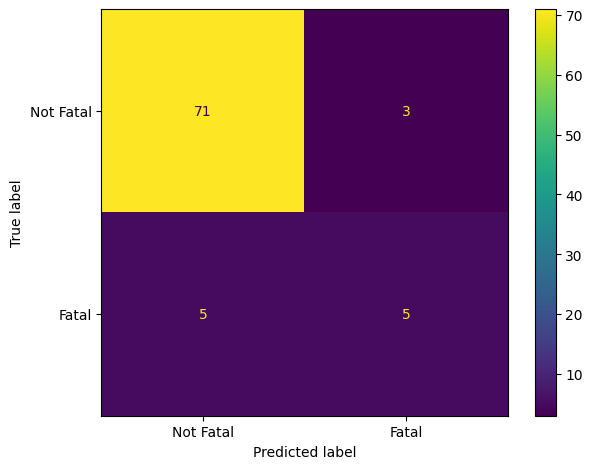

In [18]:
# Displaying the confusion matrix from the results

labels = ['Not Fatal', 'Fatal']

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
cm_display.plot() 
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                                                   Feature Coefficient
45                                        num__temperature    0.135772
29                                cat__road_type_main road    0.134191
31                              cat__road_type_residential    0.087994
16                        cat__vehicle_involved_motorcycle    0.083477
46                                      num__time_in_hours    0.079189
36                                            num__min_age    0.077779
47                                          num__rush_hour    0.063125
33                            cat__weekend_weekday_weekend    0.060310
37                                            num__max_age    0.049605
11                    cat__vehicle_involved_car-motorcycle    0.046090
39                              num__adult_driver_involved    0.038325
25                           cat__vehicle_involved_van-bus    0.030191
7                            cat__vehicle_involved_car-car    0.029365
44    

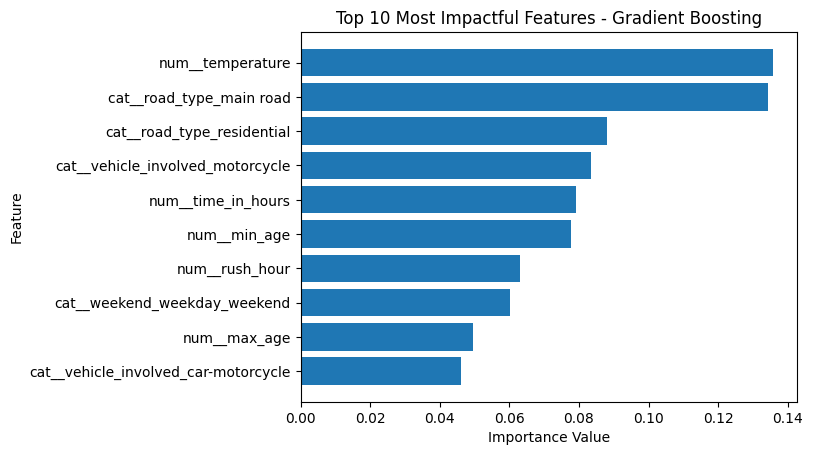

In [19]:
coef_df['Coefficient'] = coef_df['Coefficient'].astype(float)

# Display with specific float format to remove exponential notation
# Using to_string with formatters to control display without global setting changes
print(coef_df.to_string(formatters={'Coefficient': '{:.6f}'.format}))

filtered_coef_df = coef_df.head(10).sort_values('Coefficient')

x_plot = filtered_coef_df["Feature"]
y_plot = filtered_coef_df["Coefficient"]

plt.barh(x_plot, y_plot)
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.title('Top 10 Most Impactful Features - Gradient Boosting')
#plt.tight_layout()
plt.show()

In [20]:
# Transform test data
#X_test_transformed = model.named_steps["preprocess"].transform(X_test)
X_test_transformed = best_model.named_steps["preprocess"].transform(X_test)

# Optional: densify if OneHotEncoder produced sparse output
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

gradboost_model = best_model.named_steps["gradboost"]

explainer = shap.TreeExplainer(gradboost_model)
shap_values = explainer.shap_values(X_test_transformed)

shap_df = pd.DataFrame(
    np.abs(shap_values).mean(axis=0),
    index=feature_names,
    columns=["Mean |SHAP|"]
).sort_values("Mean |SHAP|", ascending=False)

print(shap_df.head(10))

                                      Mean |SHAP|
num__max_age                             1.250095
num__temperature                         1.205600
cat__vehicle_involved_car-motorcycle     1.194697
num__time_in_hours                       0.933232
cat__road_type_main road                 0.869868
cat__vehicle_involved_car-car            0.679882
num__wind_speed                          0.670312
cat__weekend_weekday_weekend             0.580968
num__min_age                             0.563424
cat__road_type_residential               0.548543


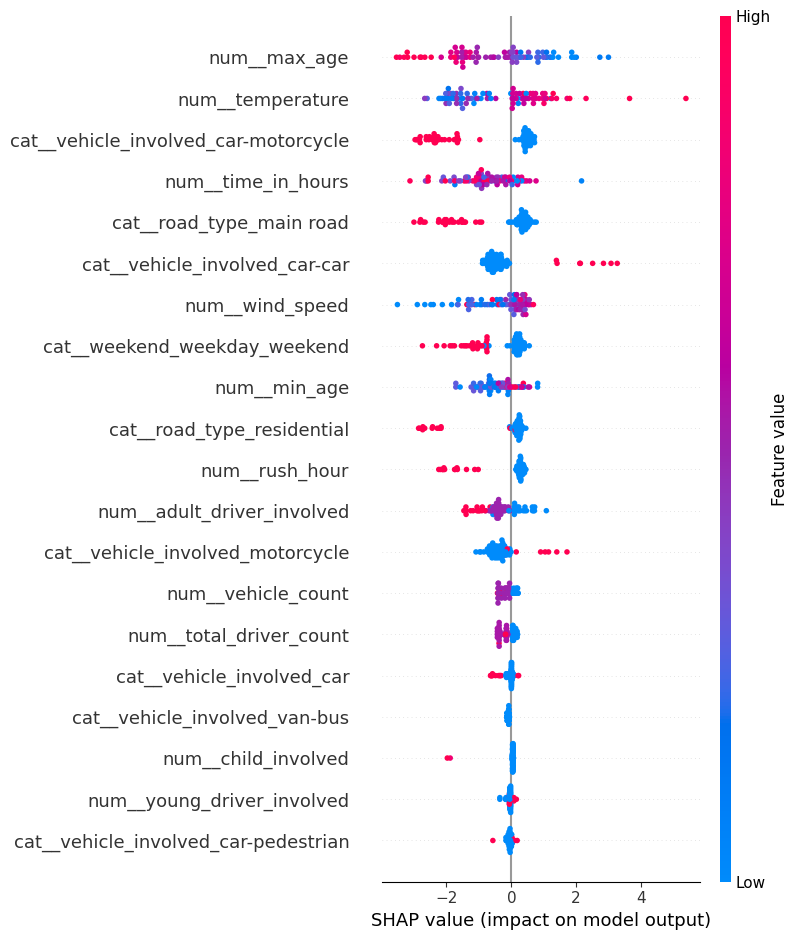

In [21]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

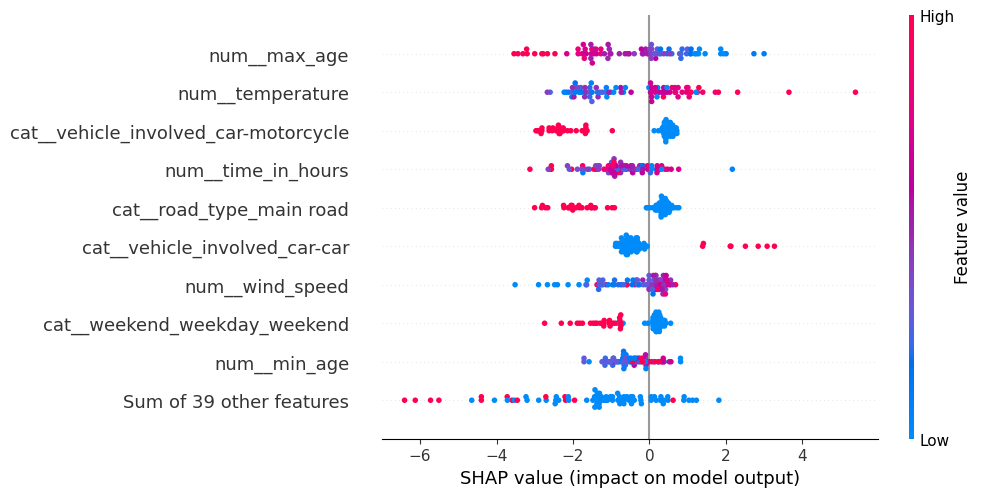

In [22]:
# Convert the processed data back to a DataFrame
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Now SHAP will automatically label the Y-axis correctly
shap_values_names = explainer(X_test_df)
shap.plots.beeswarm(shap_values_names)

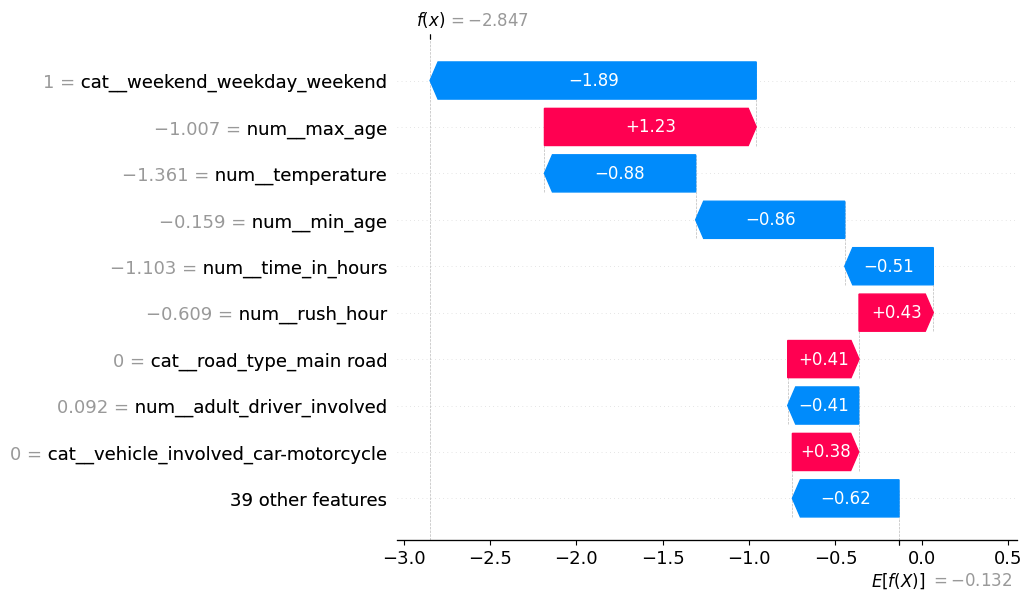

In [23]:
shap.plots.waterfall(shap_values_names[72])

In [24]:
for i, name in enumerate(feature_names):
    print(f"Feature {i}: {name}")

Feature 0: cat__vehicle_involved_bus
Feature 1: cat__vehicle_involved_bus-motorcycle
Feature 2: cat__vehicle_involved_bus-pedestrian
Feature 3: cat__vehicle_involved_bus-truck
Feature 4: cat__vehicle_involved_car
Feature 5: cat__vehicle_involved_car-bicycle
Feature 6: cat__vehicle_involved_car-bus
Feature 7: cat__vehicle_involved_car-car
Feature 8: cat__vehicle_involved_car-car-bicycle
Feature 9: cat__vehicle_involved_car-car-car
Feature 10: cat__vehicle_involved_car-car-truck
Feature 11: cat__vehicle_involved_car-motorcycle
Feature 12: cat__vehicle_involved_car-motorcycle-truck
Feature 13: cat__vehicle_involved_car-pedestrian
Feature 14: cat__vehicle_involved_car-scooter
Feature 15: cat__vehicle_involved_car-truck
Feature 16: cat__vehicle_involved_motorcycle
Feature 17: cat__vehicle_involved_motorcycle-bicycle
Feature 18: cat__vehicle_involved_motorcycle-motorcycle
Feature 19: cat__vehicle_involved_motorcycle-motorcycle-motorcycle
Feature 20: cat__vehicle_involved_motorcycle-pedestria

In [25]:
# Reviewing the actual and predicted values for each set of features
for i in range(len(X_test)):
    print(f"\nSample {i+1}")
    print(X_test.iloc[i].to_dict())
    print("Prediction:", "Fatal" if y_pred[i] == 1 else "Not Fatal")
    print("Probabilities:", y_pred_proba[i])
    print("Actual:", "Fatal" if y_test.iloc[i] == 1 else "Not Fatal")
    #print("Probabilities:", y_test.iloc)


Sample 1
{'vehicle_involved': 'car-coachman', 'vehicle_count': 2.0, 'road_type': 'main road', 'total_driver_count': 2.0, 'min_age': 31.0, 'max_age': 61.0, 'young_driver_involved': 0.0, 'adult_driver_involved': 1.0, 'senior_driver_involved': 1.0, 'child_involved': 0.0, 'senior_involved': 1.0, 'visibility': 10.0, 'wind_speed': 16.7, 'temperature': 26.0, 'time_in_hours': 1330, 'rush_hour': 0, 'weekend_weekday': 'weekday'}
Prediction: Not Fatal
Probabilities: [0.99454161 0.00545839]
Actual: Not Fatal

Sample 2
{'vehicle_involved': 'car-motorcycle', 'vehicle_count': 2.0, 'road_type': 'bypass', 'total_driver_count': 2.0, 'min_age': 33.0, 'max_age': 52.0, 'young_driver_involved': 0.0, 'adult_driver_involved': 1.0, 'senior_driver_involved': 0.0, 'child_involved': 0.0, 'senior_involved': 0.0, 'visibility': 10.0, 'wind_speed': 11.1, 'temperature': 15.0, 'time_in_hours': 1700, 'rush_hour': 1, 'weekend_weekday': 'weekend'}
Prediction: Not Fatal
Probabilities: [9.99836677e-01 1.63323137e-04]
Actua

## P-R and ROC Curve drawing

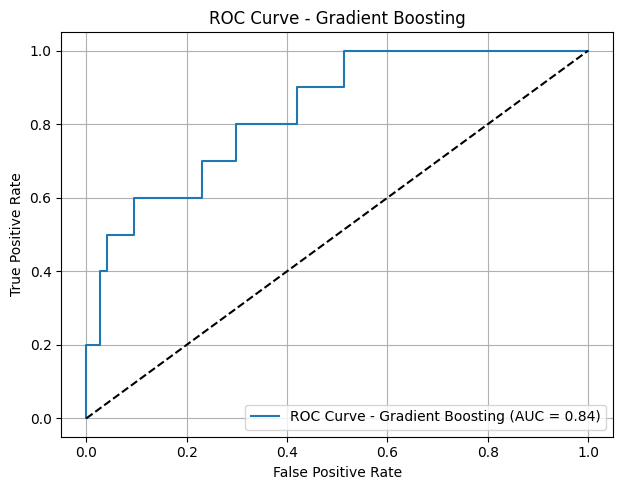

In [26]:
#y_score = model.predict_proba(X_test)[:, 1]
y_score = best_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC Curve - Gradient Boosting (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - Gradient Boosting')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

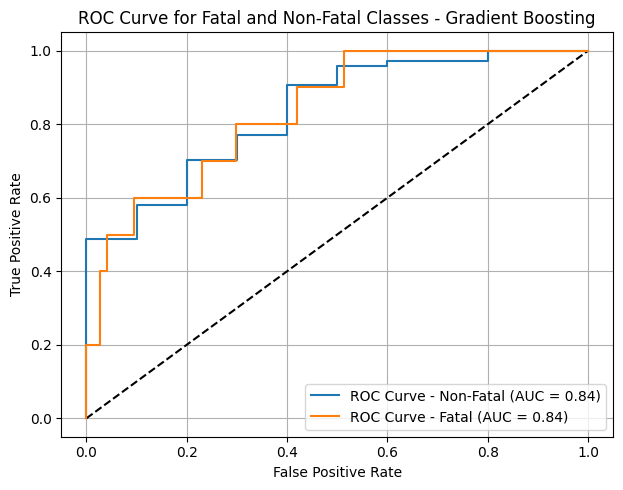

In [27]:
# ROC Curve for Individual Classes
fpr_fatal, tpr_fatal, _ = roc_curve(y_test, y_score, pos_label=1)
fpr_not_fatal, tpr_not_fatal, _ = roc_curve(y_test, y_score, pos_label=0)

#y_pred_proba_rf = best_model.predict_proba(X_test)
y_pred_proba_rf = model.predict_proba(X_test)
y_prob_rf = y_pred_proba_rf[:, 1]

plt.figure(figsize=(12, 5))

# Initialize dictionaries to store ROC curve metrics for each class
fpr_list = dict()
tpr_list = dict()
roc_auc_list = dict()

# Calculate ROC curve and AUC for each class
for i in range(2):
    fpr_list[i], tpr_list[i], _ = roc_curve(y_test == i, y_pred_proba_rf[:, i])
    roc_auc_list[i] = auc(fpr_list[i], tpr_list[i])

plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Fatal and Non-Fatal Classes - Gradient Boosting')
for i in range(2):
    plt.plot(fpr_list[i], tpr_list[i], label=f'ROC Curve - {"Fatal" if i==1 else "Non-Fatal"} (AUC = {roc_auc_list[i]:0.2f})')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

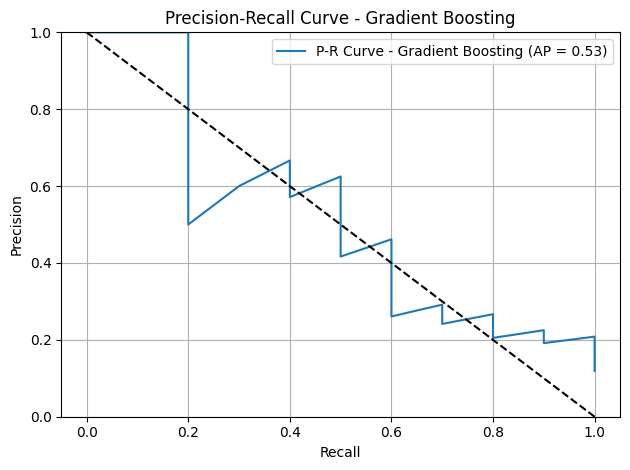

In [28]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)

#plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'P-R Curve - Gradient Boosting (AP = {ap:.2f})')
plt.plot([1, 0], [0, 1], 'k--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - Gradient Boosting')
plt.legend()
plt.ylim(0.0, 1.0)
plt.grid(True)

plt.tight_layout()
plt.show()

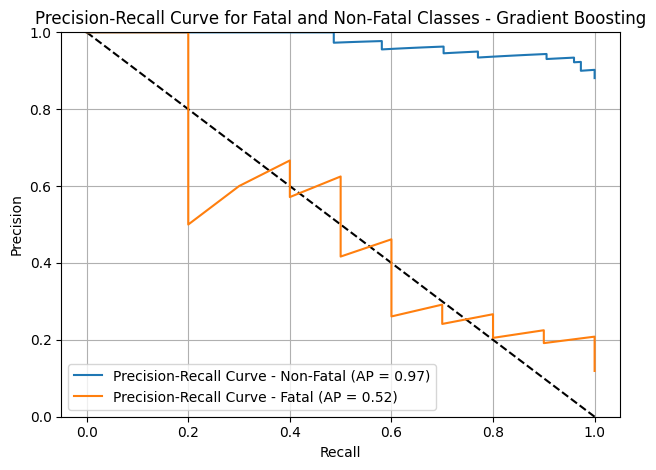

In [29]:
# Precision-Recall Curve for Fatal and Non-Fatal Classes
precision_list = dict()
recall_list = dict()
average_precision_list = dict()

# Calculate Precision-Recall curves for each class
for i in range(2):
    precision_list[i], recall_list[i], _ = precision_recall_curve(y_test == i, y_pred_proba_rf[:, i])
    average_precision_list[i] = auc(recall_list[i], precision_list[i])

#plt.subplot(1, 2, 2)
plt.plot([1, 0], [0, 1], 'k--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve for Fatal and Non-Fatal Classes - Gradient Boosting')
for i in range(2):
    plt.plot(recall_list[i], precision_list[i], label=f'Precision-Recall Curve - {"Fatal" if i==1 else "Non-Fatal"} (AP = {average_precision_list[i]:0.2f})')
plt.legend()
plt.ylim(0.0, 1.0)
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
gradboost_model.classes_

array([0, 1])

## **Interpretation**

The feature importance provided above by the model signifies that there are several factors which had a high probability of leading to fatal traffic accidents. Some of these factors include:

- Weather conditions - In particular, both temperature and wind speed often had a high influence in the final prediciton. On the other hand, visibility only had little influence in the final outcome made by the model. Despite this, it signifies that changes in weather play a huge role in the severity of traffic accidents.
- The combination of vehicles involved - Most of the predictions are heavily influenced whenever a small vehicle is involved in a given accident (i.e. bicycle, motorcycle), especially when it is involved with a larger vehicle (e.g. car-motorcycle, van-motorcycle). Additionally, any accidents which involve a single vehicle and a pedestrian also played a role in the decision-making of the model.
- Lighting conditions - While visibility was found to have little influence in the model's predictions, as mentioned above, the time of the day mattered a lot more. In fact, most of the accidents that were considered to be "Fatal" by the model occurred whenever the said accident occurred during the evening or night. This shows that improvements in lighting need to be made to minimize any risk of such accidents in the future.
- Road type - Similar to weather conditions, the type of road in which the accident occurs plays a huge role in influencing the model's predictions, with main roads and residential areas being the most influential. This signifies that measures in these areas need to be taken to reduce the likelihood of accidents occurring in these areas.

Overall, while Gradient Boosting is not fully interpretable, the ability to extract feature importance and review the model's predictions make it easier to explain the model's predictions.

## **Limitations & Ethical Considerations**

While the gradient boosting model found above has been found to perform quite well, it did come with several limitations:

- The vast majority of the accidents found in the dataset were not found to be fatal, which suggested that there was a level of bias made towards the non-fatal class, thus affecting the quality of the results generated.
- Gradient Boosting, similar to other Ensemble Learning techniques, is found to be less interpretable than other linear approaches [3]. The feature importance which is extracted by the model does not imply causation. Therefore, other interpretability techniques, such as SHAP [4], need to be integrated alongside the model to provide full explainability of the results.

There are also some ethical considerations that need to be kept in mind:

- Data privacy must be adhered to at all times, especially when planning to utilise accident data from public sources.
- The predictions generated by the model should be used to guide any decision-making processes, such as making improvements to minimize the risk of future traffic accidents, rather than to replace human judgement. They also should not be used to penalise specific areas or locations without providing the proper context.
- Transparency is required when making decisions regarding road safety or policy.

## **References**

[1] B. Clark and F. Lee, “What is gradient boosting?,” IBM, https://www.ibm.com/think/topics/gradient-boosting (accessed Jan. 7, 2026).

[2] C. Bentéjac, A. Csörgő, and G. Martínez-Muñoz, “A comparative analysis of gradient boosting algorithms,” Artif Intell Rev, vol. 54, no. 3, pp. 1937–1967, Mar. 2021, doi: 10.1007/s10462-020-09896-5.

[3] A. Natekin and A. Knoll, “Gradient boosting machines, a tutorial,” Front. Neurorobot., vol. 7, Dec. 2013, doi: 10.3389/fnbot.2013.00021.

[4] S. Dong et al., “Predicting and Analyzing Road Traffic Injury Severity Using Boosting-Based Ensemble Learning Models with SHAPley Additive exPlanations,” International Journal of Environmental Research and Public Health, vol. 19, no. 5, Mar. 2022, doi: 10.3390/ijerph19052925.